In [1]:
import torch

In [2]:
import torch.nn as nn

In [23]:
linear_model = nn.Linear(1,1)

ip = torch.tensor([[2.0], [3.1]])

linear_model(ip)

tensor([[-0.7551],
        [-1.6955]], grad_fn=<AddmmBackward0>)

In [52]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)

In [53]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

In [54]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]
train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

In [55]:
train_t_u.shape

torch.Size([9, 1])

In [26]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)** 2
    return squared_diffs.mean()

In [27]:
import torch.optim as optim

In [31]:
linear_model = nn.Linear(1,1)
learning_rate = 1e-4
optimizer = optim.SGD(linear_model.parameters(), lr=learning_rate)

In [32]:
linear_model.parameters()

<generator object Module.parameters at 0x115e57ae0>

In [33]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.9124]], requires_grad=True),
 Parameter containing:
 tensor([-0.9433], requires_grad=True)]

In [47]:
def training_loop(n_epochs, model, optimizer, loss_fn, t_u_train, t_u_val, t_c_train, t_c_val):
    for epoch in range(n_epochs):
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val)
        loss_val = loss_fn(t_p_val, t_c_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

In [56]:
training_loop(
    n_epochs=3000,
    model=linear_model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    t_u_train=train_t_u,
    t_u_val=val_t_u,
    t_c_train=train_t_c,
    t_c_val=val_t_c
)

Epoch 0, Training loss 1320.6382, Validation loss 1328.6758
Epoch 1, Training loss 220.3425, Validation loss 291.6207
Epoch 1000, Training loss 26.5243, Validation loss 23.9610
Epoch 2000, Training loss 25.5674, Validation loss 23.4631


In [57]:
linear_model.weight

Parameter containing:
tensor([[0.2792]], requires_grad=True)

In [58]:
linear_model.bias

Parameter containing:
tensor([-1.8824], requires_grad=True)

In [59]:
seq_model = nn.Sequential(
    nn.Linear(1, 13),
    nn.Tanh(),
    nn.Linear(13,1)
)

In [60]:
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [61]:
seq_model.parameters()

<generator object Module.parameters at 0x112ef7140>

In [62]:
list(seq_model.parameters())

[Parameter containing:
 tensor([[ 0.1510],
         [ 0.4584],
         [-0.3701],
         [-0.5156],
         [ 0.7759],
         [ 0.2162],
         [ 0.2557],
         [ 0.8357],
         [ 0.5566],
         [ 0.3854],
         [-0.9759],
         [-0.0910],
         [ 0.4217]], requires_grad=True),
 Parameter containing:
 tensor([-0.5772, -0.0728,  0.1798,  0.9432, -0.7427,  0.3459,  0.1316, -0.1124,
          0.0920, -0.3324,  0.5689,  0.3593, -0.5668], requires_grad=True),
 Parameter containing:
 tensor([[ 0.0522, -0.1285, -0.1436,  0.1456, -0.0470,  0.2498, -0.2648, -0.2660,
           0.1134,  0.2334,  0.0610,  0.1335, -0.2330]], requires_grad=True),
 Parameter containing:
 tensor([0.2023], requires_grad=True)]

In [63]:
[param.shape for param in list(seq_model.parameters())]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [64]:
from collections import OrderedDict

In [66]:
seq_model = nn.Sequential(
    OrderedDict([
        ('hidden_linear', nn.Linear(1,8)),
        ('activation', nn.Tanh()),
        ('output_linear', nn.Linear(8,1))
    ])
)

In [67]:
seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [68]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.0347], requires_grad=True)

In [69]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)

In [72]:
training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    model=seq_model,
    loss_fn=nn.MSELoss(),
    t_u_train=train_t_u,
    t_u_val=val_t_u,
    t_c_train=train_t_c,
    t_c_val=val_t_c   
)

Epoch 0, Training loss 215.4955, Validation loss 48.5481
Epoch 1, Training loss 208.6880, Validation loss 44.3378
Epoch 1000, Training loss 90.7284, Validation loss 19.2992
Epoch 2000, Training loss 90.7283, Validation loss 19.2992


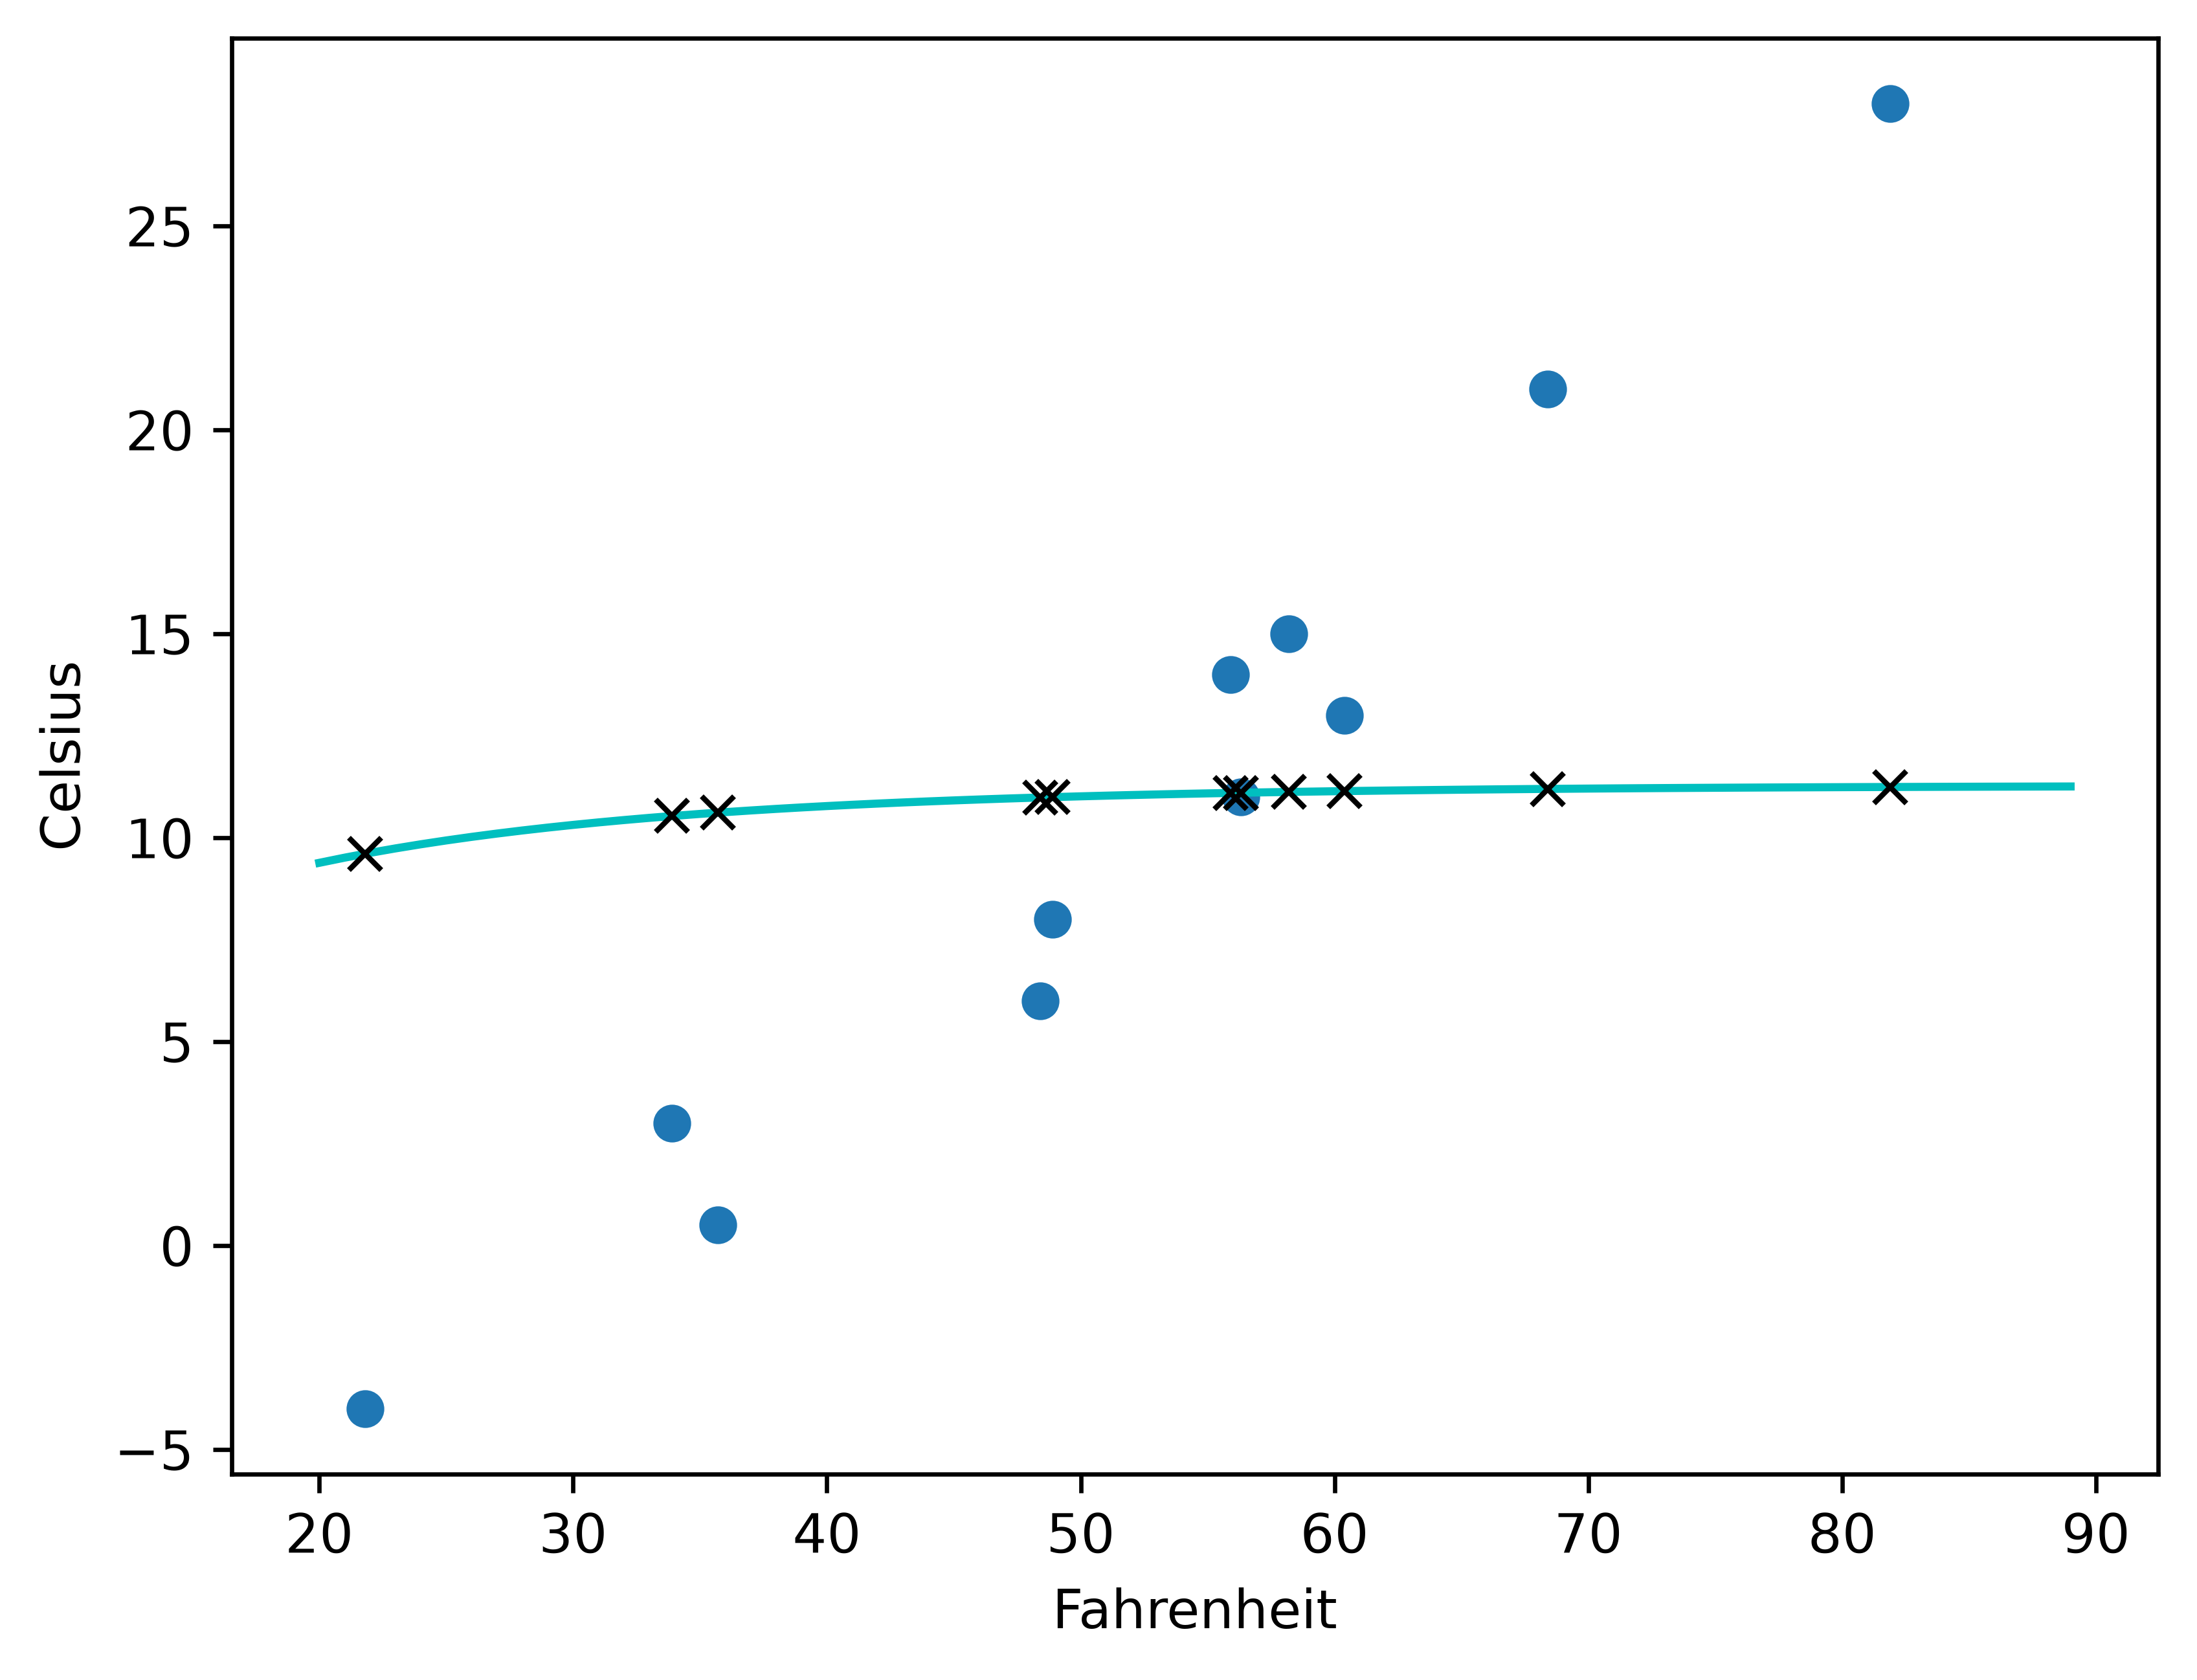

In [73]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')
